### **Load libraries**

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import risk_kit as rk
import importlib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100

### **Load data**

In [4]:
rets = pd.read_csv('../temp_references/selected_stocks_rets.csv', index_col=0)
stocks = pd.read_csv('../temp_references/selected_stocks_stocks.csv', index_col=0)

In [5]:
expected_returns = pd.read_csv('../temp_references/expected_returns.csv', index_col=0, header=None).iloc[:,0]
expected_covmat = pd.read_csv('../temp_references/expected_covmat.csv', index_col=0)

In [ ]:
# Define the number of periods per year for all calculations
# 52 for weekly, 12 for monthly
periods_per_year = 54
interval = '1wk'  # '1wk' for weekly, '1mo' for monthly
periods_to_forecast = 4  # Periods ahead predicted by the Transformer

# ─── Derived from interval (do not edit) ────────────────────────────────────
period_freq = 'W' if interval == '1wk' else 'M'
date_offset = pd.Timedelta(days=7) if interval == '1wk' else pd.DateOffset(months=1)
future_freq = 'W-SUN' if interval == '1wk' else 'MS'
time_window = periods_per_year   # Transformer input: one full year of history

# **Initial examination**

In [7]:
summary_stats = rk.summary_stats(rets, periods_per_year=periods_per_year, riskfree_rate=0)
summary_stats

,Annualized Return,Annualized Volatility,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
BOGOTA.CL,0.016595,0.284174,-0.802511,12.179730,0.063724,0.100391,0.058397,-0.633000
BVC.CL,0.140342,0.262269,0.738413,6.905517,0.044974,0.071311,0.535107,-0.356135
CELSIA.CL,0.136278,0.280082,2.584513,25.262591,0.009730,0.072082,0.486566,-0.476794
CEMARGOS.CL,0.052945,0.395404,2.577057,39.687424,0.000207,0.104767,0.133902,-0.782276
CIBEST.CL,0.200406,0.358288,0.247485,15.138579,0.060185,0.097414,0.559343,-0.581656
CNEC.CL,-0.185955,0.382439,3.085122,37.999014,-0.003558,0.103409,-0.486236,-0.923684
CONCONCRET.CL,-0.085892,1.086691,15.790625,324.354025,-2.076474,0.140517,-0.079040,-0.864859
CORFICOLCF.CL,-0.028812,0.294099,0.042956,7.811164,0.061191,0.094265,-0.097968,-0.600359
ECOPETROL.CL,0.164934,0.385332,-0.279526,9.576837,0.079148,0.112885,0.428032,-0.598050
ENKA.CL,0.052522,0.395087,1.954508,14.463180,0.039955,0.099697,0.132939,-0.562287


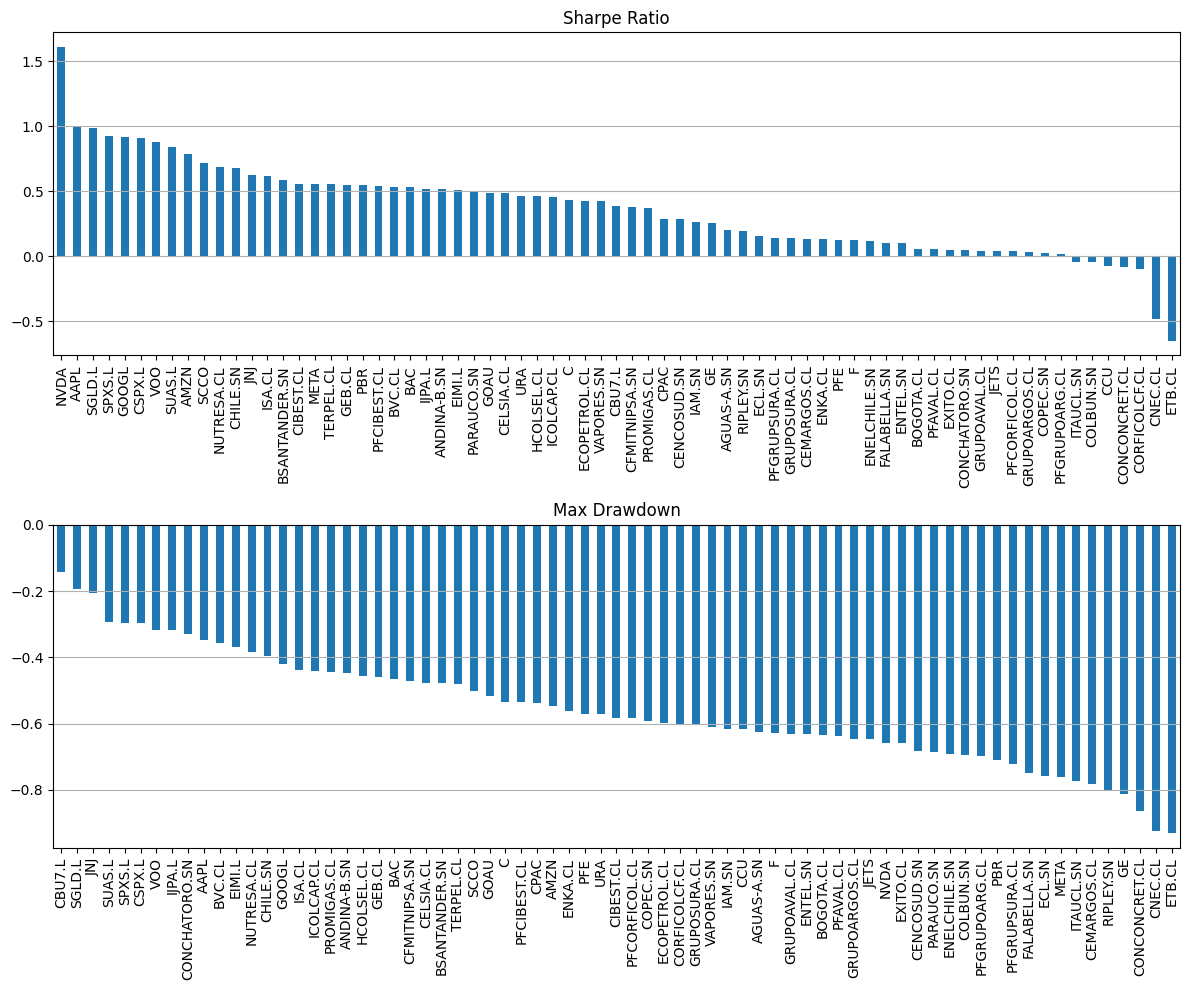

In [8]:
# Plot some return, volatility, and risk rankings to get a view of relevant stocks
summary_stats = rk.summary_stats(rets, periods_per_year=periods_per_year)
#plot1_series = summary_stats['Annualized Return'].sort_values(ascending=False)
#plot2_series = summary_stats['Annualized Volatility'].sort_values(ascending=True)
#plot1_series = summary_stats['Cornish-Fisher VaR (5%)'].sort_values(ascending=False)
#plot2_series = summary_stats['Historic CVaR (5%)'].sort_values(ascending=False)
plot1_series = summary_stats['Sharpe Ratio'].sort_values(ascending=False)
plot2_series = summary_stats['Max Drawdown'].sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
plot1_series.plot.bar(ax = axes[0], legend=False, title=plot1_series.name)
plot2_series.plot.bar(ax=axes[1], legend=False, title=plot2_series.name)
axes[0].grid(axis='y')
axes[1].grid(axis='y')
plt.tight_layout()

In [9]:
# Identify stock pairs with very high correlation

# Generate correlation matrix
corr_mat = rets.corr()
# Generate a mask to exclude  duplicated pairs
#mask = np.triu(np.ones_like(corr_mat))
#corr_mat = corr_mat*mask
# Convert the matrix into a dataframe structured as a list of pairs with their respective correlations
stack_corr = pd.DataFrame(corr_mat.stack())
stack_corr = stack_corr[stack_corr[0] < 1]
stack_corr = stack_corr[stack_corr[0] != 0]
stack_corr.index.names = ['Stock 1', 'Stock 2']
stack_corr.reset_index(inplace=True)
#(abs(stack_corr[0]) > .7).sum()

# Filter to visualize only the pairs with very high correlations
high_corrs = stack_corr[stack_corr[0] >= 0.8].sort_values(by=0, ascending=False)
high_corrs

,Stock 1,Stock 2,0
3075,CSPX.L,SPXS.L,0.998534
4663,SPXS.L,CSPX.L,0.998534
4756,SUAS.L,SPXS.L,0.968601
4686,SPXS.L,SUAS.L,0.968601
3076,CSPX.L,SUAS.L,0.967766
4733,SUAS.L,CSPX.L,0.967766
4943,VOO,CSPX.L,0.922911
3079,CSPX.L,VOO,0.922911
4689,SPXS.L,VOO,0.921793
4966,VOO,SPXS.L,0.921793


In [10]:
# Check the average correlation coefficient of each stock
stack_corr.groupby('Stock 1')[0].mean().sort_values(ascending=False)

Stock 1
VOO              0.341311
ICOLCAP.CL       0.338158
SPXS.L           0.337311
CSPX.L           0.336617
CFMITNIPSA.SN    0.336335
SUAS.L           0.328152
EIMI.L           0.313758
HCOLSEL.CL       0.295454
C                0.290385
JETS             0.283532
PFCIBEST.CL      0.280724
CIBEST.CL        0.271623
IJPA.L           0.264975
PFGRUPSURA.CL    0.264089
ITAUCL.SN        0.260684
COPEC.SN         0.260442
PFAVAL.CL        0.259036
PARAUCO.SN       0.256313
BAC              0.256230
CCU              0.245954
SCCO             0.244136
F                0.236576
ECOPETROL.CL     0.236492
CEMARGOS.CL      0.234140
GE               0.231098
CENCOSUD.SN      0.228751
FALABELLA.SN     0.227684
CORFICOLCF.CL    0.225868
BSANTANDER.SN    0.224083
URA              0.215176
GRUPOARGOS.CL    0.213835
PFGRUPOARG.CL    0.211102
ISA.CL           0.208597
GOOGL            0.208294
PBR              0.208197
RIPLEY.SN        0.199439
AAPL             0.196532
ENELCHILE.SN     0.195332
GOAU

# **Identify Combination with the maximum Sharpe-Ratio**

In [11]:
# Based on historical returns
n_periods = 162
# returns = rk.summary_stats(rets.iloc[-n_periods:], periods_per_year=periods_per_year)['Annualized Return']
# covmat = rets.iloc[-n_periods:].cov()

# Based on predicted returns
returns = expected_returns
covmat = expected_covmat

In [12]:
# Batch elimination: drop ALL stocks whose CUMULATIVE weight (ascending) is below min_weight.
# Stocks are sorted by weight ascending; we accumulate and cut where the running total < min_weight.
rf_rate = .11   # Currently, the 10-Y  bond yield is at 11.2%
max_weight = 0.15 # The maximum weight allowed for a stock
min_weight = 0.05 # The minimum weight allowed for a stock
initial_weights = rk.msr_tuned(riskfree_rate=rf_rate,
                         returns=returns,
                         covmat=covmat,
                         max_weight=max_weight,
                         periods_per_year=periods_per_year,
                         debug=True)
optimal_allocation = pd.DataFrame(data=initial_weights, index=returns.index, columns=['Weights']).sort_values(by='Weights')

iteration = 0
while optimal_allocation['Weights'].sum() >= .9999:
    iteration += 1
    # Cumulative sum of weights (already sorted ascending)
    cum_weights = optimal_allocation['Weights'].cumsum()
    # A stock is dropped if its cumulative weight is still below the threshold
    failing_mask = cum_weights < min_weight
    if not failing_mask.any():
        break  # all cumulative weights meet the threshold — done
    n_dropped = failing_mask.sum()
    print(f"  [pass {iteration}] Dropping {n_dropped} stock(s) with cumulative weight < {min_weight:.0%}: "
          f"{list(optimal_allocation[failing_mask].index)}")
    # Drop the entire sub-threshold batch at once
    optimal_allocation = optimal_allocation[~failing_mask]
    if len(optimal_allocation) <= 2:
        break
    w = rk.msr_tuned(
        riskfree_rate=rf_rate,
        returns=returns[optimal_allocation.index],
        covmat=covmat.loc[optimal_allocation.index, optimal_allocation.index],
        max_weight=max_weight,
        periods_per_year=periods_per_year,
        debug=True
    )
    optimal_allocation = (
        pd.DataFrame(w, index=optimal_allocation.index, columns=['Weights'])
        .sort_values(by='Weights')
    )

# while optimal_allocation['Weights'].min() < min_weight and len(optimal_allocation) > 2:
#     optimal_allocation = optimal_allocation.iloc[1:]
#     w = rk.msr_tuned(
#         riskfree_rate=rf_rate, 
#         returns=returns[optimal_allocation.index],
#         covmat=covmat.loc[optimal_allocation.index, optimal_allocation.index],
#         max_weight=max_weight, 
#         periods_per_year=periods_per_year
#     )
#     optimal_allocation = (
#         pd.DataFrame(w, index=optimal_allocation.index, columns=['Weights'])
#         .sort_values(by='Weights')
#     )

chosen_allocation = optimal_allocation
chosen_allocation

  NIT    FC           OBJFUN            GNORM
  [iter   1] Sharpe: 46.175293 | Ret: 1.0108 | Vol: 0.0195
    1    73    -4.617529E+01     2.781421E+02
  [iter   2] Sharpe: 45.897876 | Ret: 0.8928 | Vol: 0.0171
    2   145    -4.589788E+01     1.461410E+02
  [iter   3] Sharpe: 34.075094 | Ret: 0.6868 | Vol: 0.0169
    3   218    -3.407509E+01     1.753925E+02
  [iter   4] Sharpe: 33.374429 | Ret: 0.6837 | Vol: 0.0172
    4   291    -3.337443E+01     2.012384E+02
  [iter   5] Sharpe: 35.905428 | Ret: 0.6914 | Vol: 0.0162
    5   364    -3.590543E+01     2.161118E+02
  [iter   6] Sharpe: 46.702369 | Ret: 0.9156 | Vol: 0.0173
    6   437    -4.670237E+01     2.247698E+02
  [iter   7] Sharpe: 48.817059 | Ret: 0.8760 | Vol: 0.0157
    7   510    -4.881706E+01     2.223619E+02
  [iter   8] Sharpe: 48.624509 | Ret: 0.8497 | Vol: 0.0152
    8   583    -4.862451E+01     2.208071E+02
  [iter   9] Sharpe: 39.108939 | Ret: 0.7954 | Vol: 0.0175
    9   656    -3.910894E+01     2.232008E+02
  [iter  

  [iter  14] Sharpe: 51.467043 | Ret: 0.8564 | Vol: 0.0145
   14  1025    -5.146704E+01     2.198666E+02
  [iter  15] Sharpe: 45.575375 | Ret: 0.8267 | Vol: 0.0157
   15  1098    -4.557537E+01     2.181235E+02
  [iter  16] Sharpe: 52.712003 | Ret: 0.8628 | Vol: 0.0143
   16  1172    -5.271200E+01     2.191488E+02
  [iter  17] Sharpe: 53.002816 | Ret: 0.8513 | Vol: 0.0140
   17  1246    -5.300282E+01     2.191032E+02
  [iter  18] Sharpe: 51.192201 | Ret: 0.8865 | Vol: 0.0152
   18  1319    -5.119220E+01     2.202699E+02
  [iter  19] Sharpe: 54.271029 | Ret: 0.8665 | Vol: 0.0139
   19  1393    -5.427103E+01     2.201737E+02
  [iter  20] Sharpe: 53.932657 | Ret: 0.8631 | Vol: 0.0140
   20  1466    -5.393266E+01     2.189490E+02
  [iter  21] Sharpe: 54.320885 | Ret: 0.8621 | Vol: 0.0138
   21  1539    -5.432088E+01     2.181444E+02
  [iter  22] Sharpe: 53.962396 | Ret: 0.8795 | Vol: 0.0143
   22  1612    -5.396240E+01     2.180680E+02


  [iter  23] Sharpe: 54.323229 | Ret: 0.8692 | Vol: 0.0140
   23  1686    -5.432323E+01     2.178963E+02
  [iter  24] Sharpe: 54.306368 | Ret: 0.8642 | Vol: 0.0139
   24  1759    -5.430637E+01     2.176520E+02
  [iter  25] Sharpe: 54.292410 | Ret: 0.8663 | Vol: 0.0139
   25  1833    -5.429241E+01     2.176375E+02
  [iter  26] Sharpe: 54.337746 | Ret: 0.8649 | Vol: 0.0139
   26  1906    -5.433775E+01     2.176070E+02
  [iter  27] Sharpe: 54.339188 | Ret: 0.8647 | Vol: 0.0139
   27  1979    -5.433919E+01     2.173642E+02
  [iter  28] Sharpe: 54.339190 | Ret: 0.8646 | Vol: 0.0139
   28  2051    -5.433919E+01     2.172980E+02
  [iter  29] Sharpe: 54.339192 | Ret: 0.8646 | Vol: 0.0139
   29  2123    -5.433919E+01     2.173599E+02
  [iter  30] Sharpe: 54.339192 | Ret: 0.8646 | Vol: 0.0139
   30  2194    -5.433919E+01     2.173384E+02
Optimization terminated successfully    (Exit mode 0)
            Current function value: -54.339191889230676
            Iterations: 30
            Function ev

  [iter   7] Sharpe: 50.382607 | Ret: 0.9085 | Vol: 0.0158
    7   108    -5.038261E+01     2.787030E+01
  [iter   8] Sharpe: 47.341130 | Ret: 0.8576 | Vol: 0.0158
    8   123    -4.734113E+01     2.759973E+01
  [iter   9] Sharpe: 48.050377 | Ret: 0.8450 | Vol: 0.0153
    9   139    -4.805038E+01     2.758384E+01
  [iter  10] Sharpe: 52.468637 | Ret: 0.9209 | Vol: 0.0155
   10   155    -5.246864E+01     2.743579E+01
  [iter  11] Sharpe: 52.894659 | Ret: 0.8723 | Vol: 0.0144
   11   170    -5.289466E+01     2.856884E+01
  [iter  12] Sharpe: 46.173302 | Ret: 0.7716 | Vol: 0.0143
   12   185    -4.617330E+01     2.826228E+01
  [iter  13] Sharpe: 49.572725 | Ret: 0.8577 | Vol: 0.0151
   13   201    -4.957272E+01     2.808685E+01
  [iter  14] Sharpe: 53.568751 | Ret: 0.8686 | Vol: 0.0142
   14   217    -5.356875E+01     2.788717E+01
  [iter  15] Sharpe: 51.843850 | Ret: 0.8657 | Vol: 0.0146
   15   232    -5.184385E+01     2.765377E+01
  [iter  16] Sharpe: 54.225320 | Ret: 0.8747 | Vol: 0.0

  [iter   4] Sharpe: 39.913764 | Ret: 0.8152 | Vol: 0.0177
    4    53    -3.991376E+01     2.622558E+01
  [iter   5] Sharpe: 48.619135 | Ret: 0.9483 | Vol: 0.0172
    5    67    -4.861914E+01     2.513877E+01
  [iter   6] Sharpe: 48.691513 | Ret: 0.9088 | Vol: 0.0164
    6    81    -4.869151E+01     2.498454E+01
  [iter   7] Sharpe: 50.752382 | Ret: 0.8874 | Vol: 0.0153
    7    95    -5.075238E+01     2.518303E+01
  [iter   8] Sharpe: 48.389637 | Ret: 0.8828 | Vol: 0.0160
    8   109    -4.838964E+01     2.499743E+01
  [iter   9] Sharpe: 52.108191 | Ret: 0.9333 | Vol: 0.0158
    9   123    -5.210819E+01     2.494968E+01
  [iter  10] Sharpe: 53.698864 | Ret: 0.8876 | Vol: 0.0145
   10   137    -5.369886E+01     2.507276E+01
  [iter  11] Sharpe: 53.217294 | Ret: 0.8921 | Vol: 0.0147
   11   150    -5.321729E+01     2.547289E+01
  [iter  12] Sharpe: 51.112330 | Ret: 0.8818 | Vol: 0.0151
   12   163    -5.111233E+01     2.527413E+01
  [iter  13] Sharpe: 53.812915 | Ret: 0.9000 | Vol: 0.0

,Weights
0,
PFGRUPOARG.CL,0.052905
PBR,0.069532
PROMIGAS.CL,0.070430
BOGOTA.CL,0.075470
NVDA,0.103258
ENKA.CL,0.110102
CPAC,0.114891
PFCIBEST.CL,0.125114
AAPL,0.128296


In [13]:
"""
# Alternative methodology finding the combination that maximizes the Sharpe ratio and then removing any stock with a weight below 5%
rf_rate = .11   # Currently, the 10-Y  bond yield is at 11.2%

weights = rk.msr(riskfree_rate=rf_rate, return_series=rets, periods_per_year=periods_per_year)
optimal_allocation = pd.DataFrame(data=weights.round(4), index=rets.columns, columns=['Weights'])
optimal_allocation = optimal_allocation[optimal_allocation['Weights'] >= .05]

# Reduce the portfolio stocks to only those for which shares of over 3% is recommended
chosen_allocation = optimal_allocation[optimal_allocation['Weights'] > .05]
chosen_allocation = chosen_allocation / chosen_allocation.sum()
chosen_allocation.sort_values(by='Weights')
"""

"\n# Alternative methodology finding the combination that maximizes the Sharpe ratio and then removing any stock with a weight below 5%\nrf_rate = .11   # Currently, the 10-Y  bond yield is at 11.2%\n\nweights = rk.msr(riskfree_rate=rf_rate, return_series=rets, periods_per_year=periods_per_year)\noptimal_allocation = pd.DataFrame(data=weights.round(4), index=rets.columns, columns=['Weights'])\noptimal_allocation = optimal_allocation[optimal_allocation['Weights'] >= .05]\n\n# Reduce the portfolio stocks to only those for which shares of over 3% is recommended\nchosen_allocation = optimal_allocation[optimal_allocation['Weights'] > .05]\nchosen_allocation = chosen_allocation / chosen_allocation.sum()\nchosen_allocation.sort_values(by='Weights')\n"

<Axes: xlabel='Date'>

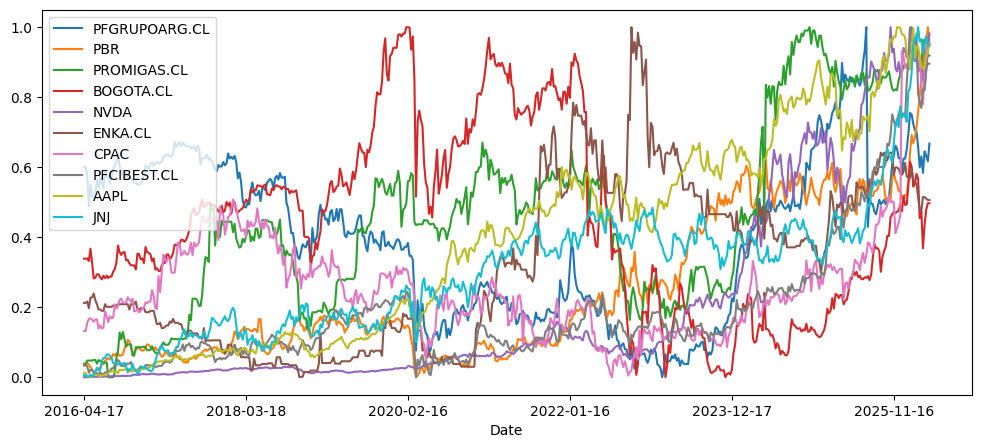

In [14]:
normalized_stocks = (stocks - stocks.min()) / (stocks.max() - stocks.min())
normalized_stocks[optimal_allocation.index].plot(figsize=(12, 5))

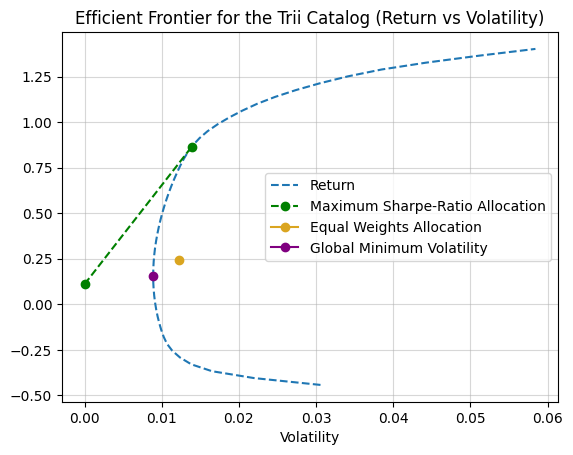

In [15]:
rk.plot_ef(50, style='--', show_cml=True, show_ew=True, show_gmv=True, riskfree_rate=rf_rate,
           returns=returns, covmat=covmat, periods_per_year=periods_per_year)
plt.title('Efficient Frontier for the Trii Catalog (Return vs Volatility)')
plt.grid(alpha=.5)

# **Create an index for the chosen allocation**

In [ ]:
# Generate a dataframe to represent the evolution of the allocation in each stock
weights = chosen_allocation['Weights']
allocated_index = (rets[weights.index] + 1).cumprod()*weights

# Add a column to represent the index
allocated_index['index'] = allocated_index.sum(axis='columns')
allocated_index.index = pd.to_datetime(allocated_index.index.str.split('/').str[0])

# Generate a row to represent an earlier period before returns are made,
# corresponding to the time when the index equal 1
first_period = allocated_index.index[0]
starting_period = first_period - (pd.offsets.Week(weekday=6) if interval == '1wk' else pd.DateOffset(months=1))
starting_period

allocation_start = pd.DataFrame(index=[starting_period], columns=allocated_index.columns)
allocation_start.iloc[:, :-1] = 1*weights
allocation_start['index'] = 1

# Append the row to the allocated_index dataframe
allocated_index = pd.concat([allocation_start, allocated_index], axis='rows')
allocated_index.head()

In [17]:
# Generate a dataframe with the returns of the index
allocated_index_returns = (allocated_index/allocated_index.shift(1) - 1).dropna()
allocated_index_returns.tail()

,PFGRUPOARG.CL,PBR,PROMIGAS.CL,BOGOTA.CL,NVDA,ENKA.CL,CPAC,PFCIBEST.CL,AAPL,JNJ,index
2026-03-22,-0.051163,0.012386,0.065831,-0.1,-0.041834,0.052632,-0.046418,0.05332,-0.008516,-0.025464,-0.035268
2026-03-29,0.070261,0.104787,-0.014706,0.070175,-0.029994,0.0,0.078307,-0.001553,0.003266,0.021583,-0.021093
2026-04-05,-0.01374,-0.010111,-0.028358,0.043049,0.058918,-0.005556,0.053975,0.057437,0.028617,0.010771,0.052731
2026-04-12,-0.017028,0.046206,0.012289,0.017368,0.063363,-0.005587,-0.002793,0.015256,0.017818,-0.018845,0.055814
2026-04-19,0.056322,-0.045095,0.0,0.0,0.054286,0.0,0.006536,0.0,0.022842,0.000881,0.046358


In [18]:
summary_stats = rk.summary_stats(allocated_index_returns, periods_per_year=periods_per_year, riskfree_rate=0)
summary_stats

,Annualized Return,Annualized Volatility,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
PFGRUPOARG.CL,0.007535,0.370579,-0.683944,23.146148,0.070324,0.112689,0.020332,-0.698413
PBR,0.264178,0.483733,-0.186221,6.354844,0.100710,0.137473,0.546124,-0.710030
PROMIGAS.CL,0.109423,0.294855,1.865256,26.760319,0.020161,0.085143,0.371106,-0.444339
BOGOTA.CL,0.016595,0.284174,-0.802511,12.179730,0.063724,0.100391,0.058397,-0.633000
NVDA,0.750350,0.465919,0.353382,4.522084,0.083432,0.116430,1.610475,-0.659360
ENKA.CL,0.052522,0.395087,1.954508,14.463180,0.039955,0.099697,0.132939,-0.562287
CPAC,0.096722,0.339238,2.689774,33.481110,0.003253,0.091462,0.285116,-0.537636
PFCIBEST.CL,0.168013,0.309577,-0.175048,9.971343,0.061663,0.089149,0.542717,-0.536017
AAPL,0.283113,0.281457,-0.186234,5.080669,0.058032,0.082069,1.005884,-0.346407
JNJ,0.111273,0.178417,-0.201058,4.689743,0.038226,0.051279,0.623668,-0.205645


In [ ]:
# Build formatted allocation output with PORTFOLIO INDEX row
investment_cop = 105_000_000  # Total capital available (COP)
cop_per_stock = (weights * investment_cop / 1_000).round(2)

portfolio_stats = rk.summary_stats(
    allocated_index_returns[['index']],
    periods_per_year=periods_per_year,
    riskfree_rate=rf_rate
).loc['index']

portfolio_forecasted = (
    cop_per_stock * (1 + expected_returns[weights.index]) ** (periods_to_forecast / periods_per_year)
).sum().round(2)

allocation_output = pd.DataFrame({
    'Portfolio Weight':       weights.round(4),
    'Expected Annual Return': expected_returns[weights.index].round(4),
    'Current Price':          stocks.iloc[-1][weights.index].round(4),
    'Investment (COP k)':     cop_per_stock,
}).sort_values('Portfolio Weight', ascending=False)

portfolio_row = pd.DataFrame({
    'Portfolio Weight':          [1],
    'Expected Annual Return':    [round(portfolio_stats['Annualized Return'], 4)],
    'Current Price':             [cop_per_stock.sum()],
    'Forecasted Value (COP k)':  [portfolio_forecasted],
    'Investment (COP k)':        [cop_per_stock.sum()],
}, index=['PORTFOLIO INDEX'])

allocation_output = pd.concat([allocation_output, portfolio_row])
allocation_output

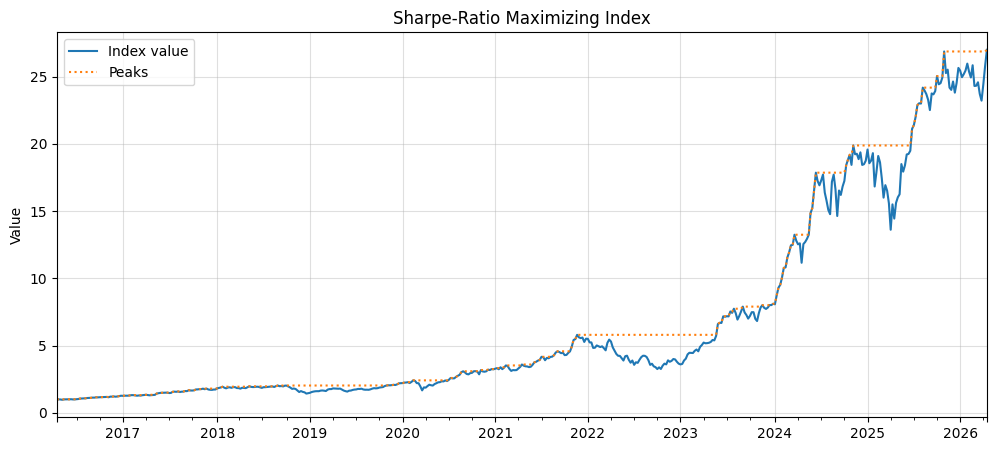

In [19]:
# Visualize the evolution of the index
allocated_index['index'].plot(figsize=(12, 5), label='Index value')
allocated_index['index'].cummax().plot(linestyle=':', label='Peaks')
plt.legend()
plt.ylabel('Value')
plt.title('Sharpe-Ratio Maximizing Index')
plt.grid(alpha=0.4)

### **Export datasets and an index for the Sharpe-Ratio maximizing allocation**

In [20]:
# Allocation index and returns
allocated_index.to_csv('../temp_references/allocated_index.csv')
allocated_index_returns.to_csv('../temp_references/allocated_index_returns.csv')